# Set Up

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL: Imports
# ═══════════════════════════════════════════════════════════════════════════

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, ttest_ind, t as t_dist
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir, skip_subs

# Font fallback (cluster-safe)
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams['font.family'] = 'sans-serif'

# Output directory for figures
FIG_DIR = '/user_data/csimmon2/git_repos/sym_pt/C_results/figures'
os.makedirs(FIG_DIR, exist_ok=True)

# Random seed for reproducibility
RNG = np.random.default_rng(42)
N_ITER = 100000

# Categories and color conventions
CATEGORIES = ['face', 'house', 'object', 'word']
UNILATERAL = ['face', 'word']
BILATERAL  = ['house', 'object']
COLORS = {'L-res': '#6B8AAD', 'R-res': '#E07A8B'}
PANEL_COLORS = {'unilateral': '#F4E4EF', 'bilateral': '#DCE8DC'}

# Subject exclusions
EXCLUDE = ['sub-017']  # polymicrogyria

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL: Data load
# ═══════════════════════════════════════════════════════════════════════════

# ── Selectivity (sum_selec_norm, mean_act, volume) ──────────────────────
SEL_PATH = '/user_data/csimmon2/sym_pt/group_results/selectivity/selectivity_summary.csv'
df_sel = pd.read_csv(SEL_PATH)
df_sel = df_sel[~df_sel['sub'].isin(EXCLUDE)]

# Cross-sectional: first session per subject
df_sel_cs = df_sel.sort_values(['sub','ses']).drop_duplicates(['sub','category','hemi'])

# Longitudinal: subjects with ≥2 sessions
ses_counts = df_sel.groupby('sub')['ses'].nunique()
long_subs = ses_counts[ses_counts >= 2].index
df_long = df_sel[df_sel['sub'].isin(long_subs)].copy()
first_last = df_long.groupby('sub')['ses'].agg(['min','max']).reset_index()
first_last = first_last[first_last['min'] != first_last['max']]
df_t1 = df_long.merge(first_last[['sub','min']], on='sub')
df_t1 = df_t1[df_t1['ses'] == df_t1['min']].drop(columns='min')
df_tl = df_long.merge(first_last[['sub','max']], on='sub')
df_tl = df_tl[df_tl['ses'] == df_tl['max']].drop(columns='max')

# ── Peak coordinates ────────────────────────────────────────────────────
PEAK_PATH = '/user_data/csimmon2/sym_pt/group_results/peak_coords/peak_coords.csv'
df_peak = pd.read_csv(PEAK_PATH)
df_peak = df_peak[~df_peak['sub'].isin(EXCLUDE)]
df_peak['ses'] = df_peak['ses'].astype(int)
df_peak_cs = df_peak.sort_values(['sub','ses']).drop_duplicates(['sub','category','hemi'])

# ── Distinctiveness (Liu) ───────────────────────────────────────────────
LIU_PATH = '/user_data/csimmon2/sym_pt/group_results/liu_distinctiveness/liu_distinctiveness_differential.csv'
df_liu = pd.read_csv(LIU_PATH)
df_liu = df_liu[~df_liu['subject_id'].isin(EXCLUDE)]

# ── Geometry / cosine (from voxel_allegiance output) ────────────────────
# Adjust path if needed
VA_PATH = '/user_data/csimmon2/sym_pt/group_results/voxel_allegiance_summary_cat_vs_all.csv'
if os.path.exists(VA_PATH):
    df_va = pd.read_csv(VA_PATH)
    df_va = df_va[~df_va['sub'].isin(EXCLUDE)]
else:
    df_va = None
    print(f'Voxel allegiance CSV not found at {VA_PATH}')

print(f'Selectivity: {df_sel["sub"].nunique()} subs, {len(df_sel_cs)} cross-sectional rows')
print(f'Longitudinal: {df_t1["sub"].nunique()} subs')
print(f'Peak coords: {df_peak["sub"].nunique()} subs')

Selectivity: 49 subs, 948 cross-sectional rows
Longitudinal: 17 subs
Peak coords: 49 subs


# Cross Sectional

## Peak Distance — Cross-Sectional

### Measure
For each subject, find the peak voxel (max z-stat, z>2.3) within the Harvard-Oxford category searchmask in MNI space. Compute the mean Euclidean distance from that peak to all control peaks for the same category and hemisphere. One value per subject × category × hemisphere (mm).

### Control reference
For each category × hemisphere, compute each control's mean distance to the other controls (leave-one-out). Average across controls = control mean distance. Captures typical anatomical variability in peak location.

### Patient value
Patient distance − control mean distance = how much further (or closer) the patient's peak sits from the control distribution than controls sit from each other. Positive = more displaced than typical. Negative = peak falls near the ctrl centroid.

### Categories shown
Face, word (unilateral); house_PPA, object (bilateral). House here = house_PPA sub-ROI only (combined house mask dropped for sub-ROI analysis per Liu 2025).

### Groups
L-resection (n=8, intact RH vs Ctrl RH) and R-resection (n=8, intact LH vs Ctrl LH). Anatomical homolog comparison. Sub-017 excluded (polymicrogyria).

### Figure 1 — Individual categories
Each dot = one patient. Diamond + whiskers = group mean ± 95% CI. Open circle = group median (robust to outliers; divergence from mean indicates outlier influence).

### Figure 2 — Bilateral vs Unilateral
Each line = one patient. Left point = mean of (face, word) distances; right point = mean of (house, object) distances. Horizontal dashed line at zero = control level.

### Interpretation
Values above zero indicate displacement beyond typical control variability. Pattern consistency across patients and categories is the primary evidence; individual category p-values are underpowered given n=8 per group.

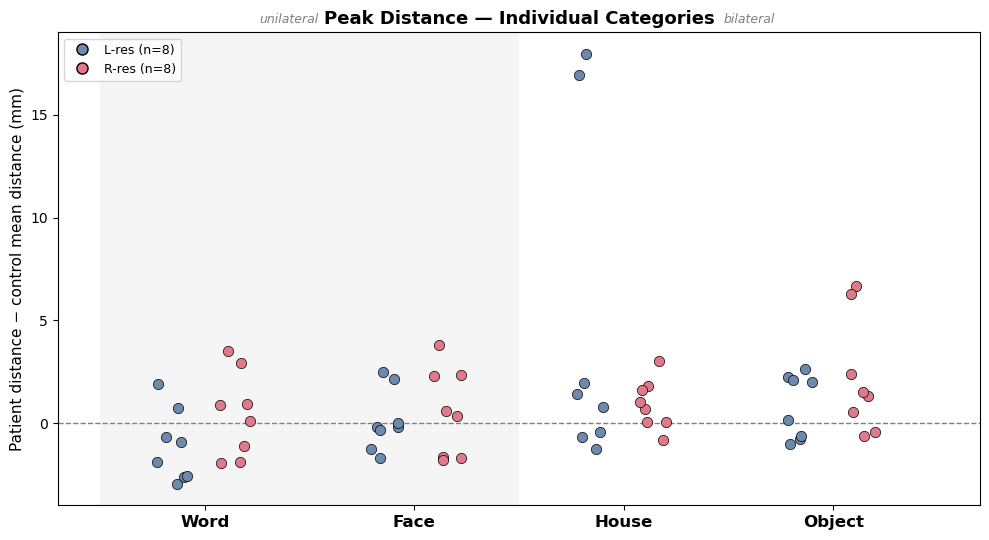

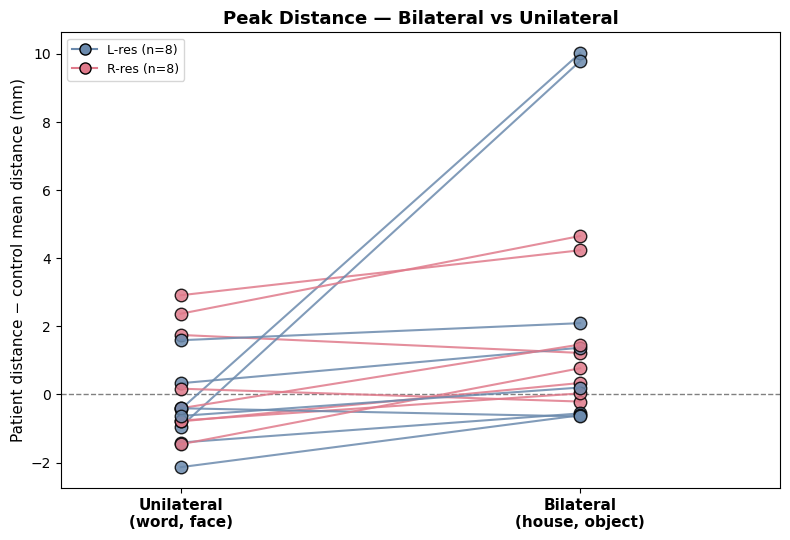

In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL: Peak Distance — cross-sectional, patient vs control
# ═══════════════════════════════════════════════════════════════════════════

CATS_ORDERED = ['word', 'face', 'house_PPA', 'object']
LABELS = {'word': 'Word', 'face': 'Face', 'object': 'Object', 'house_PPA': 'House'}

rows = []
for cat in CATS_ORDERED:
    for hemi in ['left', 'right']:
        ctrl = df_peak_cs[(df_peak_cs['group']=='control') &
                          (df_peak_cs['category']==cat) &
                          (df_peak_cs['hemi']==hemi)][['peak_x_mni','peak_y_mni','peak_z_mni']].values
        if len(ctrl) < 2:
            continue
        ctrl_dists = []
        for i in range(len(ctrl)):
            others = np.delete(ctrl, i, axis=0)
            ctrl_dists.append(np.sqrt(((others - ctrl[i])**2).sum(axis=1)).mean())
        ctrl_mean = np.mean(ctrl_dists)

        pts = df_peak_cs[(df_peak_cs['group']=='OTC') &
                         (df_peak_cs['category']==cat) &
                         (df_peak_cs['hemi']==hemi) &
                         (df_peak_cs['intact_hemi']==hemi)]
        for _, r in pts.iterrows():
            d = np.sqrt(((ctrl - [r.peak_x_mni, r.peak_y_mni, r.peak_z_mni])**2).sum(axis=1)).mean()
            rows.append({
                'sub': r['sub'],
                'resection': 'L-res' if hemi=='right' else 'R-res',
                'category': cat,
                'dist_mm': d,
                'ctrl_mean_mm': ctrl_mean,
                'rel_ctrl_mm': d - ctrl_mean,
            })

df_peak_rel = pd.DataFrame(rows)

# ── Figure 1: per-category ──────────────────────────────────────────────
PANEL_COLORS = {'unilateral': '#F5F5F5', 'bilateral': '#FFFFFF'}

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.axvspan(-0.5, 1.5, color=PANEL_COLORS['unilateral'], alpha=1.0, zorder=0)
ax.axvspan(1.5, 3.5, color=PANEL_COLORS['bilateral'], alpha=1.0, zorder=0)
ax.axhline(0, color='gray', linestyle='--', linewidth=1, zorder=1)

for i, cat in enumerate(CATS_ORDERED):
    sub = df_peak_rel[df_peak_rel['category'] == cat]
    for res, grp in sub.groupby('resection'):
        offset = -0.15 if res == 'L-res' else 0.15
        jitter = np.random.default_rng(i).uniform(-0.08, 0.08, len(grp))
        ax.scatter(i + offset + jitter, grp['rel_ctrl_mm'],
                   s=55, color=COLORS[res], edgecolor='black',
                   linewidth=0.5, zorder=3)

ax.set_xticks(range(4))
ax.set_xticklabels([LABELS[c] for c in CATS_ORDERED], fontsize=12, fontweight='bold')
ax.set_ylabel('Patient distance − control mean distance (mm)', fontsize=11)
ax.set_title('Peak Distance — Individual Categories', fontsize=13, fontweight='bold')
ax.text(0.25, 1.02, 'unilateral', transform=ax.transAxes, ha='center',
        style='italic', fontsize=9, color='gray')
ax.text(0.75, 1.02, 'bilateral', transform=ax.transAxes, ha='center',
        style='italic', fontsize=9, color='gray')
handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLORS[k],
                       markeredgecolor='k', markersize=8, label=f'{k} (n=8)')
           for k in ['L-res', 'R-res']]
ax.legend(handles=handles, loc='upper left', fontsize=9)
plt.tight_layout()
#plt.savefig(f'{FIG_DIR}/fig_peak_distance_categories.png', dpi=200)
plt.show()

# ── Figure 2: slope plot ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.axhline(0, color='gray', linestyle='--', linewidth=1, zorder=1)

for sub, sd in df_peak_rel.groupby('sub'):
    uni = sd[sd['category'].isin(['word', 'face'])]['rel_ctrl_mm'].mean()
    bi  = sd[sd['category'].isin(['house_PPA', 'object'])]['rel_ctrl_mm'].mean()
    res = sd['resection'].iloc[0]
    ax.plot([0, 1], [uni, bi], '-o', color=COLORS[res], markersize=9,
            markeredgecolor='black', linewidth=1.5, alpha=0.85, zorder=3)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Unilateral\n(word, face)', 'Bilateral\n(house, object)'],
                    fontsize=11, fontweight='bold')
ax.set_xlim(-0.3, 1.5)
ax.set_ylabel('Patient distance − control mean distance (mm)', fontsize=11)
ax.set_title('Peak Distance — Bilateral vs Unilateral', fontsize=13, fontweight='bold')
handles = [plt.Line2D([0],[0], marker='o', color=COLORS[k],
                       markeredgecolor='k', markersize=8, label=f'{k} (n=8)')
           for k in ['L-res', 'R-res']]
ax.legend(handles=handles, loc='upper left', fontsize=9)
plt.tight_layout()
#plt.savefig(f'{FIG_DIR}/fig_peak_distance_slope.png', dpi=200)
plt.show()

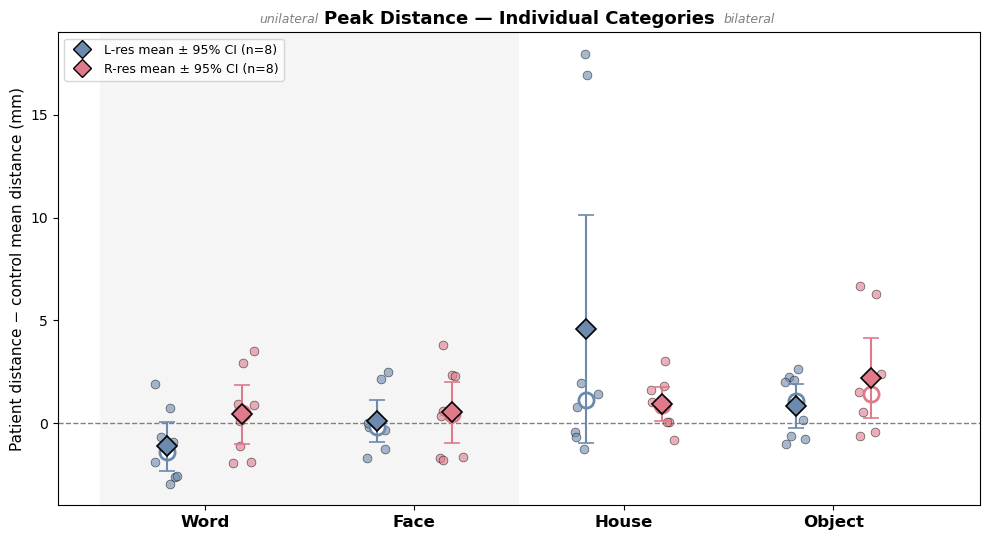

In [18]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.axvspan(-0.5, 1.5, color='#F5F5F5', zorder=0)
ax.axvspan(1.5, 3.5, color='#FFFFFF', zorder=0)
ax.axhline(0, color='gray', linestyle='--', linewidth=1, zorder=1)

# Compute mean, median, trimmed mean (drop min+max)
def trimmed_mean(x):
    s = np.sort(x)
    return s[1:-1].mean() if len(s) > 2 else s.mean()

for i, cat in enumerate(CATS_ORDERED):
    for res in ['L-res', 'R-res']:
        grp = df_peak_rel[(df_peak_rel['category']==cat) & (df_peak_rel['resection']==res)]['rel_ctrl_mm'].values
        offset = -0.18 if res == 'L-res' else 0.18
        x = i + offset
        
        # Individual points
        jitter = np.random.default_rng(i*10 + (0 if res=='L-res' else 1)).uniform(-0.06, 0.06, len(grp))
        ax.scatter(x + jitter, grp, s=40, color=COLORS[res], edgecolor='black',
                   linewidth=0.5, alpha=0.6, zorder=3)
        
        # Median (robust to outliers) - open circle
        med = np.median(grp)
        ax.scatter(x, med, s=120, marker='o', facecolor='white', edgecolor=COLORS[res],
                   linewidth=2, zorder=5)
        
        # Mean ± 95% CI - diamond
        m = np.mean(grp)
        se = np.std(grp, ddof=1) / np.sqrt(len(grp))
        ax.errorbar(x, m, yerr=1.96*se, fmt='D', color=COLORS[res],
                    markersize=10, markeredgecolor='black', markeredgewidth=1.2,
                    capsize=6, capthick=1.5, elinewidth=1.5, zorder=6)


ax.set_xticks(range(4))
ax.set_xticklabels([LABELS[c] for c in CATS_ORDERED], fontsize=12, fontweight='bold')
ax.set_ylabel('Patient distance − control mean distance (mm)', fontsize=11)
ax.set_title('Peak Distance — Individual Categories', fontsize=13, fontweight='bold')

ax.text(0.25, 1.02, 'unilateral', transform=ax.transAxes, ha='center', style='italic', fontsize=9, color='gray')
ax.text(0.75, 1.02, 'bilateral', transform=ax.transAxes, ha='center', style='italic', fontsize=9, color='gray')
handles = [plt.Line2D([0],[0], marker='D', color=COLORS[k], markeredgecolor='k',
                       markersize=9, linestyle='', label=f'{k} mean ± 95% CI (n=8)')
           for k in ['L-res', 'R-res']]
ax.legend(handles=handles, loc='upper left', fontsize=9)
plt.tight_layout()
#plt.savefig(f'{FIG_DIR}/fig_peak_distance_categories.png', dpi=200)
plt.show()

### Statistical tests

Two mixed ANOVAs (group × category), one per hemisphere. FDR-corrected (BH, q=.05).

**RH (L-res vs Ctrl):** Group × Category p=.029. Post-hoc: house_PPA displaced (6.7 vs 3.1 mm); object borderline (7.6 vs 6.8 mm); face and word match controls.

**LH (R-res vs Ctrl):** Group p=.033, no interaction. Elevation concentrated in object (8.3 vs 6.1 mm, outside ctrl CI [5.5, 6.8]).

At the individual-patient level (bootstrap CI, 97.5th percentile of ctrl-to-ctrl distance): house_PPA 5/8 L-res and 4/8 R-res displaced; object 5/8 L-res and 4/8 R-res; face 2/8 and 2/8; word displacement driven by count not distance.

## Sum Selectivity — Cross-Sectional

### Measure
Sum selectivity = sum of z-stats across all voxels exceeding z>2.3 within the category searchmask, normalized by searchmask volume. Combines magnitude and spatial extent (Ayzenberg 2023).

### Patient value
Patient sum selectivity − control mean. Positive = elevated (often reorganization to intact hemi); negative = reduced selectivity.

### Categories shown
Face, word (unilateral); house (combined), object (bilateral). Combined house used here (not house_PPA sub-ROI).

### Groups
L-resection (n=8, intact RH vs Ctrl RH) and R-resection (n=8, intact LH vs Ctrl LH).

### Figure
Each dot = one patient. Diamond + whiskers = group mean ± 95% CI. Open circle = group median.

### Statistical tests
Two mixed ANOVAs (group × category), one per hemisphere. FDR-corrected.

**RH (L-res vs Ctrl):** ns (selectivity preserved).

**LH (R-res vs Ctrl):** Group p=.035, Group × Category p<.001. Object reduced (942 vs 1942, outside ctrl CI [1455, 2428]); face elevated (445 vs 299, outside ctrl CI [176, 434]) — consistent with reorganization to intact LH.

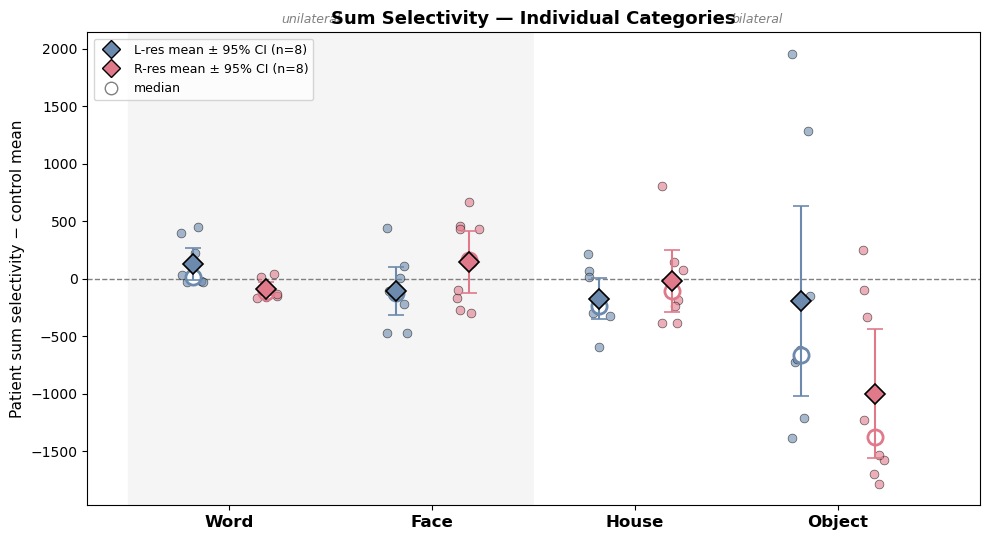

In [21]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL: Sum Selectivity — cross-sectional, patient vs control
# ═══════════════════════════════════════════════════════════════════════════

CATS_ORDERED = ['word', 'face', 'house', 'object']
LABELS = {'word': 'Word', 'face': 'Face', 'house': 'House', 'object': 'Object'}
METRIC = 'sum_selec_norm'

# Compute patient value − ctrl mean per cat × hemi
rows = []
for cat in CATS_ORDERED:
    for hemi in ['left', 'right']:
        ctrl_vals = df_sel_cs[(df_sel_cs['group']=='control') &
                              (df_sel_cs['category']==cat) &
                              (df_sel_cs['hemi']==hemi)][METRIC].dropna().values
        if len(ctrl_vals) < 2: continue
        ctrl_mean = np.mean(ctrl_vals)
        
        pts = df_sel_cs[(df_sel_cs['group']=='OTC') &
                        (df_sel_cs['category']==cat) &
                        (df_sel_cs['hemi']==hemi) &
                        (df_sel_cs['intact_hemi']==hemi)]
        for _, r in pts.iterrows():
            rows.append({
                'sub': r['sub'],
                'resection': 'L-res' if hemi=='right' else 'R-res',
                'category': cat,
                'sum_sel': r[METRIC],
                'ctrl_mean': ctrl_mean,
                'rel_ctrl': r[METRIC] - ctrl_mean,
            })

df_sel_rel = pd.DataFrame(rows)

# ── Figure: per-category with mean ± CI and median ──────────────────────
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.axvspan(-0.5, 1.5, color='#F5F5F5', zorder=0)
ax.axvspan(1.5, 3.5, color='#FFFFFF', zorder=0)
ax.axhline(0, color='gray', linestyle='--', linewidth=1, zorder=1)

for i, cat in enumerate(CATS_ORDERED):
    for res in ['L-res', 'R-res']:
        grp = df_sel_rel[(df_sel_rel['category']==cat) & (df_sel_rel['resection']==res)]['rel_ctrl'].values
        offset = -0.18 if res == 'L-res' else 0.18
        x = i + offset
        
        jitter = np.random.default_rng(i*10 + (0 if res=='L-res' else 1)).uniform(-0.06, 0.06, len(grp))
        ax.scatter(x + jitter, grp, s=40, color=COLORS[res], edgecolor='black',
                   linewidth=0.5, alpha=0.6, zorder=3)
        
        med = np.median(grp)
        ax.scatter(x, med, s=120, marker='o', facecolor='white', edgecolor=COLORS[res],
                   linewidth=2, zorder=5)
        
        m = np.mean(grp)
        se = np.std(grp, ddof=1) / np.sqrt(len(grp))
        ax.errorbar(x, m, yerr=1.96*se, fmt='D', color=COLORS[res],
                    markersize=10, markeredgecolor='black', markeredgewidth=1.2,
                    capsize=6, capthick=1.5, elinewidth=1.5, zorder=6)

ax.set_xticks(range(4))
ax.set_xticklabels([LABELS[c] for c in CATS_ORDERED], fontsize=12, fontweight='bold')
ax.set_ylabel('Patient sum selectivity − control mean', fontsize=11)
ax.set_title('Sum Selectivity — Individual Categories', fontsize=13, fontweight='bold')
ax.text(0.25, 1.02, 'unilateral', transform=ax.transAxes, ha='center', style='italic', fontsize=9, color='gray')
ax.text(0.75, 1.02, 'bilateral', transform=ax.transAxes, ha='center', style='italic', fontsize=9, color='gray')
handles = [plt.Line2D([0],[0], marker='D', color=COLORS[k], markeredgecolor='k',
                       markersize=9, linestyle='', label=f'{k} mean ± 95% CI (n=8)')
           for k in ['L-res', 'R-res']]
handles.append(plt.Line2D([0],[0], marker='o', color='w', markeredgecolor='gray',
                           markersize=9, linestyle='', label='median'))
ax.legend(handles=handles, loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_sum_selectivity_categories.png', dpi=200)
plt.show()

### Statistical tests

Two mixed ANOVAs (group × category), one per hemisphere. FDR-corrected (BH, q=.05).

**RH (L-res vs Ctrl):** ns (selectivity preserved despite displacement).

**LH (R-res vs Ctrl):** Group p=.035, Group × Category p<.001. Object reduced (942 vs 1942, outside ctrl CI [1455, 2428]); face elevated (445 vs 299, outside ctrl CI [176, 434]) — consistent with reorganization to intact LH.

At the individual-patient level (bootstrap CI): object reduced in 5/8 L-res and 6/8 R-res; house reduced in 3/8 L-res and 2/8 R-res; face elevated in 3/8 R-res (reorganization to intact hemi).

## Representational Distinctiveness — Cross-Sectional

### Measure
Fisher-z transformed Pearson correlation between the preferred category response and non-preferred categories within a 6 mm sphere around the category peak. Higher = preferred category LESS distinguishable from non-preferred categories (more "blurred" representation). Lower = sharper, more distinct representation. Ayzenberg 2023 / Liu 2025 method, computed on raw betas (copes 15–18).

### Why Fisher-z
Correlations are bounded [-1, 1] and non-normal. Fisher-z stretches values for proper parametric comparison.

### Patient value
Patient distinctiveness − control mean. Positive = less distinct than controls (disruption). Negative = sharper than controls.

### Categories shown
Face, word (unilateral); house, object (bilateral). Combined house (not house_PPA sub-ROI) for the main category plot.

### Groups
L-resection (n=8, intact RH vs Ctrl RH) and R-resection (n=8, intact LH vs Ctrl LH).

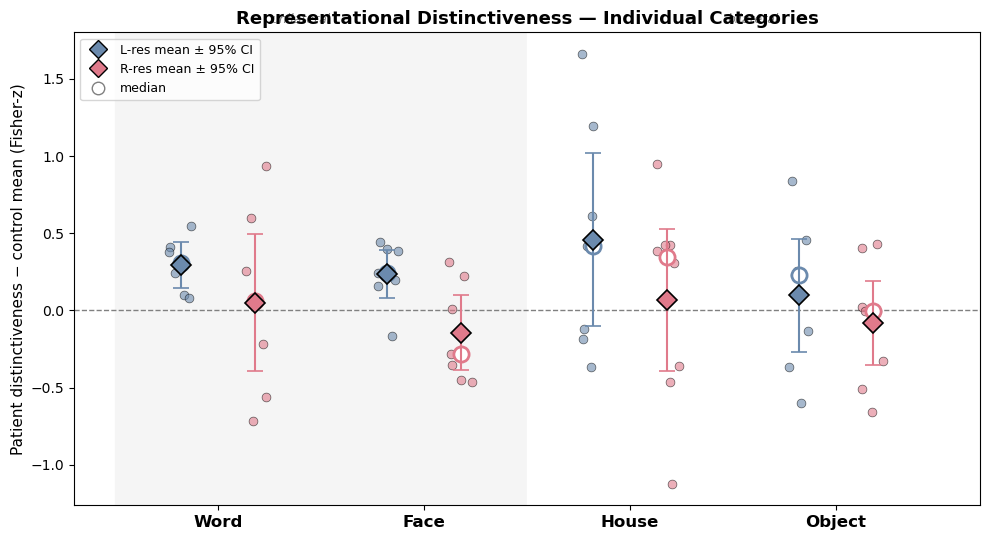

In [25]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL: Distinctiveness — cross-sectional, patient vs control
# ═══════════════════════════════════════════════════════════════════════════

CATS_ORDERED = ['word', 'face', 'house', 'object']
LABELS = {'word': 'Word', 'face': 'Face', 'house': 'House', 'object': 'Object'}

# df_liu columns assumed: subject_id, group, status, surgery_side, category, hemi_label, liu_value (or similar)
# Adjust value column name if needed
VCOL = 'liu_distinctiveness'

# Cross-sectional: first session per subject
df_liu_cs = df_liu.sort_values(['subject_id']).drop_duplicates(['subject_id','category','hemi_label'])

rows = []
for cat in CATS_ORDERED:
    for hemi in ['left', 'right']:
        # Ctrl: hemi_label is actual hemi
        ctrl_vals = df_liu_cs[(df_liu_cs['status']=='control') &
                            (df_liu_cs['category']==cat) &
                            (df_liu_cs['hemi_label']==hemi)][VCOL].dropna().values
        if len(ctrl_vals) < 2: continue
        ctrl_mean = np.mean(ctrl_vals)
        
        # Patient: intact hemi = opposite of surgery_side
        pts = df_liu_cs[(df_liu_cs['group']=='OTC') &
                        (df_liu_cs['category']==cat) &
                        (df_liu_cs['hemi_label']=='intact')]
        pts = pts[((pts['surgery_side']=='right') & (hemi=='left')) |
                ((pts['surgery_side']=='left')  & (hemi=='right'))]
        for _, r in pts.iterrows():
            rows.append({
                'sub': r['subject_id'],
                'resection': 'L-res' if r['surgery_side']=='left' else 'R-res',
                'category': cat,
                'liu': r[VCOL],
                'ctrl_mean': ctrl_mean,
                'rel_ctrl': r[VCOL] - ctrl_mean,
            })

df_liu_rel = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.axvspan(-0.5, 1.5, color='#F5F5F5', zorder=0)
ax.axvspan(1.5, 3.5, color='#FFFFFF', zorder=0)
ax.axhline(0, color='gray', linestyle='--', linewidth=1, zorder=1)

for i, cat in enumerate(CATS_ORDERED):
    for res in ['L-res', 'R-res']:
        grp = df_liu_rel[(df_liu_rel['category']==cat) & (df_liu_rel['resection']==res)]['rel_ctrl'].values
        if len(grp) == 0: continue
        offset = -0.18 if res == 'L-res' else 0.18
        x = i + offset
        
        jitter = np.random.default_rng(i*10 + (0 if res=='L-res' else 1)).uniform(-0.06, 0.06, len(grp))
        ax.scatter(x + jitter, grp, s=40, color=COLORS[res], edgecolor='black',
                   linewidth=0.5, alpha=0.6, zorder=3)
        
        med = np.median(grp)
        ax.scatter(x, med, s=120, marker='o', facecolor='white', edgecolor=COLORS[res],
                   linewidth=2, zorder=5)
        
        m = np.mean(grp)
        se = np.std(grp, ddof=1) / np.sqrt(len(grp))
        ax.errorbar(x, m, yerr=1.96*se, fmt='D', color=COLORS[res],
                    markersize=10, markeredgecolor='black', markeredgewidth=1.2,
                    capsize=6, capthick=1.5, elinewidth=1.5, zorder=6)

ax.set_xticks(range(4))
ax.set_xticklabels([LABELS[c] for c in CATS_ORDERED], fontsize=12, fontweight='bold')
ax.set_ylabel('Patient distinctiveness − control mean (Fisher-z)', fontsize=11)
ax.set_title('Representational Distinctiveness — Individual Categories', fontsize=13, fontweight='bold')
ax.text(0.25, 1.02, 'unilateral', transform=ax.transAxes, ha='center', style='italic', fontsize=9, color='gray')
ax.text(0.75, 1.02, 'bilateral', transform=ax.transAxes, ha='center', style='italic', fontsize=9, color='gray')
handles = [plt.Line2D([0],[0], marker='D', color=COLORS[k], markeredgecolor='k',
                       markersize=9, linestyle='', label=f'{k} mean ± 95% CI')
           for k in ['L-res', 'R-res']]
handles.append(plt.Line2D([0],[0], marker='o', color='w', markeredgecolor='gray',
                           markersize=9, linestyle='', label='median'))
ax.legend(handles=handles, loc='upper left', fontsize=9)
plt.tight_layout()
#plt.savefig(f'{FIG_DIR}/fig_distinctiveness_categories.png', dpi=200)
plt.show()

### Statistical tests

Two mixed ANOVAs (group × category), one per hemisphere. FDR-corrected (BH, q=.05).

**RH (L-res vs Ctrl):** Group p=.048, no interaction. Uniform reduction in distinctiveness across categories (all less distinct than ctrl).

**LH (R-res vs Ctrl):** ns.

At the individual-patient level: house_PPA sub-ROI less distinct in L-res (0.451 vs ctrl CI [-0.169, 0.250]); word less distinct in both groups (RH 0.822 vs [0.042, 0.748]; LH 0.796 vs [0.288, 0.719]).

# Longitudinal

## Peak Drift — Longitudinal

### Measure
Euclidean distance (mm) between peak voxel MNI coordinates at T1 vs T2 for each subject × category × hemisphere. Measures how much the peak moved between sessions.

### Patient value
Patient drift − control mean drift. Positive = patient moved more than typical ctrl variability.

### Groups
5 OTC patients (3 L-res, 2 R-res) vs 9 matched controls. Sub-017 excluded.

### Note on power
n=5 does not support ANOVA. Bootstrap CI (10K, LOO) for group-level comparisons; Crawford-Howell t for individual patients.

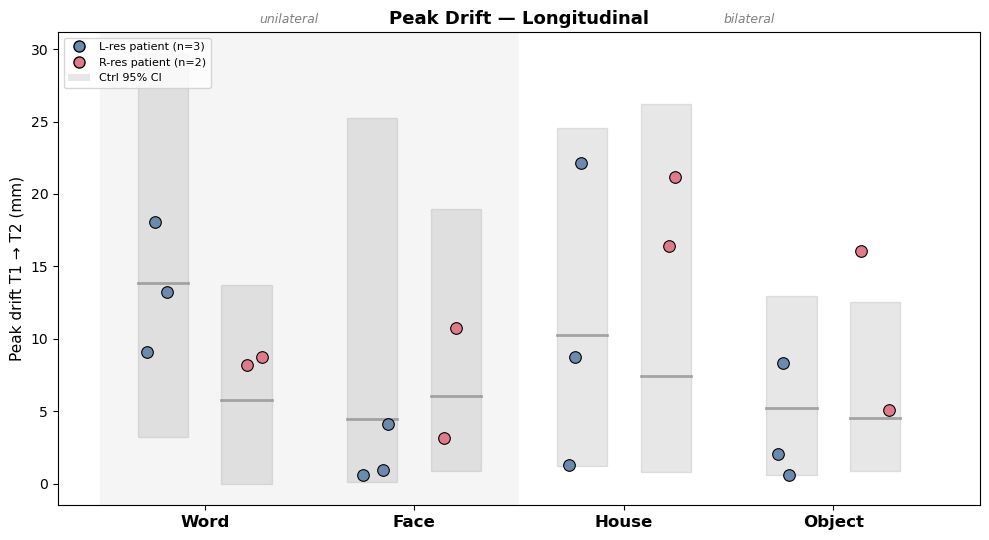

In [28]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.axvspan(-0.5, 1.5, color='#F5F5F5', zorder=0)
ax.axvspan(1.5, 3.5, color='#FFFFFF', zorder=0)

CTRL_COLOR = '#888888'

for i, cat in enumerate(CATS_ORDERED):
    for res, hemi_ctrl in [('L-res', 'right'), ('R-res', 'left')]:
        ctrl_vals = drift[(drift['group']=='control') &
                          (drift['category']==cat) &
                          (drift['hemi']==hemi_ctrl)]['drift_mm'].values
        if len(ctrl_vals) < 2: continue
        offset = -0.2 if res == 'L-res' else 0.2
        x = i + offset
        
        lo, hi = np.percentile(ctrl_vals, [2.5, 97.5])
        m = np.mean(ctrl_vals)
        ax.fill_between([x - 0.12, x + 0.12], [lo, lo], [hi, hi],
                        color=CTRL_COLOR, alpha=0.2, zorder=1)
        ax.plot([x - 0.12, x + 0.12], [m, m], color=CTRL_COLOR,
                linewidth=2, alpha=0.7, zorder=2)
        
        pt_vals = drift[(drift['group']=='OTC') & (drift['category']==cat) &
                        (drift['hemi']==hemi_ctrl) & (drift['intact_hemi']==hemi_ctrl)]['drift_mm'].values
        jitter = np.random.default_rng(i*10 + (0 if res=='L-res' else 1)).uniform(-0.08, 0.08, len(pt_vals))
        ax.scatter(x + jitter, pt_vals, s=70, color=COLORS[res], edgecolor='black',
                   linewidth=0.8, zorder=4)

ax.set_xticks(range(4))
ax.set_xticklabels([LABELS[c] for c in CATS_ORDERED], fontsize=12, fontweight='bold')
ax.set_ylabel('Peak drift T1 → T2 (mm)', fontsize=11)
ax.set_title('Peak Drift — Longitudinal', fontsize=13, fontweight='bold')
ax.text(0.25, 1.02, 'unilateral', transform=ax.transAxes, ha='center', style='italic', fontsize=9, color='gray')
ax.text(0.75, 1.02, 'bilateral', transform=ax.transAxes, ha='center', style='italic', fontsize=9, color='gray')

from matplotlib.patches import Patch
handles = [
    plt.Line2D([0],[0], marker='o', color=COLORS['L-res'], markeredgecolor='k',
               markersize=8, linestyle='', label='L-res patient (n=3)'),
    plt.Line2D([0],[0], marker='o', color=COLORS['R-res'], markeredgecolor='k',
               markersize=8, linestyle='', label='R-res patient (n=2)'),
    Patch(facecolor=CTRL_COLOR, alpha=0.2, label='Ctrl 95% CI'),
]
ax.legend(handles=handles, loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_peak_drift_long_categories.png', dpi=200)
plt.show()

### Statistical tests (longitudinal)

Bootstrap CI (10K, LOO) for group comparisons; Crawford-Howell t per patient.

**Group-level:** R-res object outside CI (10.6 mm vs ctrl CI [1.0, 10.4]). All other cells within CI.

**Per-patient (Crawford):** sub-008 object t=2.71, p=.027 (drives R-res object group flag). All other patients/categories ns.

**Note:** Group flag on R-res object is driven by sub-008; sub-004 object drift is 5.08 mm (within CI).

## Sum Selectivity — Longitudinal

### Measure
Δ sum selectivity = T2 − T1 of the cross-sectional metric (sum of z-stats across selective voxels, normalized by searchmask volume). Positive = patient gained selectivity over time; negative = lost.

### Patient value
Raw Δ plotted. Ctrl 95% CI captures typical developmental change over matched interval.

### Groups
5 OTC (3 L-res, 2 R-res) vs 9 matched ctrls. Ctrl shown as gray band (95% CI of paired T2−T1 change), patients as individual colored dots.

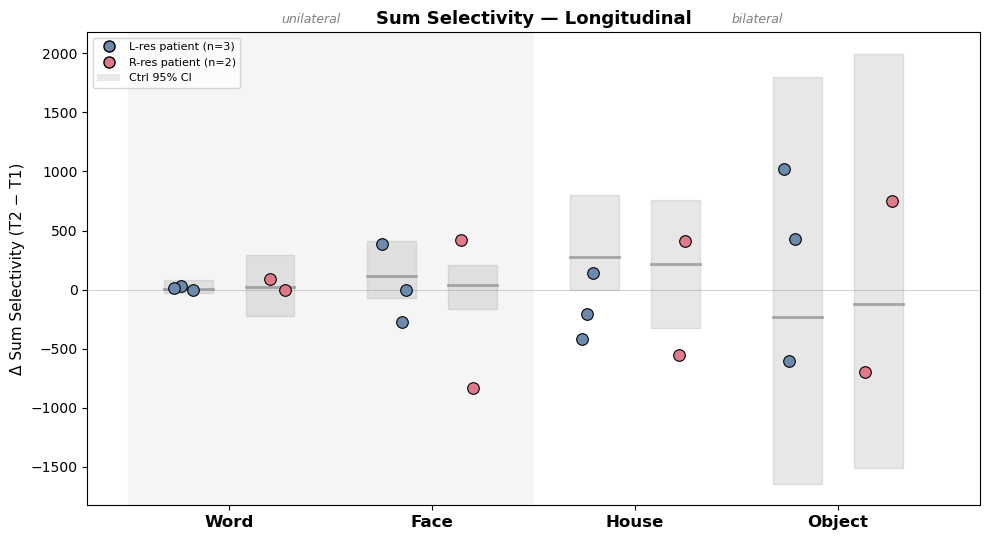

In [30]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL: Sum Selectivity — longitudinal Δ
# ═══════════════════════════════════════════════════════════════════════════

CATS_ORDERED = ['word', 'face', 'house', 'object']
LABELS = {'word': 'Word', 'face': 'Face', 'house': 'House', 'object': 'Object'}
METRIC = 'sum_selec_norm'
CTRL_COLOR = '#888888'

# Build Δ dataframe from df_t1, df_tl (loaded earlier)
delta_rows = []
for sub in df_t1['sub'].unique():
    s1 = df_t1[df_t1['sub'] == sub]
    s2 = df_tl[df_tl['sub'] == sub]
    if s1.empty or s2.empty: continue
    for _, r1 in s1.iterrows():
        r2 = s2[(s2['category']==r1['category']) & (s2['hemi']==r1['hemi'])]
        if r2.empty: continue
        delta_rows.append({
            'sub': sub,
            'group': r1['group'],
            'intact_hemi': r1['intact_hemi'],
            'category': r1['category'],
            'hemi': r1['hemi'],
            'delta': r2[METRIC].values[0] - r1[METRIC],
        })
df_delta = pd.DataFrame(delta_rows)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.axvspan(-0.5, 1.5, color='#F5F5F5', zorder=0)
ax.axvspan(1.5, 3.5, color='#FFFFFF', zorder=0)
ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)

for i, cat in enumerate(CATS_ORDERED):
    for res, hemi_ctrl in [('L-res', 'right'), ('R-res', 'left')]:
        ctrl_vals = df_delta[(df_delta['group']=='control') &
                             (df_delta['category']==cat) &
                             (df_delta['hemi']==hemi_ctrl)]['delta'].values
        if len(ctrl_vals) < 2: continue
        offset = -0.2 if res == 'L-res' else 0.2
        x = i + offset
        
        lo, hi = np.percentile(ctrl_vals, [2.5, 97.5])
        m = np.mean(ctrl_vals)
        ax.fill_between([x - 0.12, x + 0.12], [lo, lo], [hi, hi],
                        color=CTRL_COLOR, alpha=0.2, zorder=1)
        ax.plot([x - 0.12, x + 0.12], [m, m], color=CTRL_COLOR,
                linewidth=2, alpha=0.7, zorder=2)
        
        pt_vals = df_delta[(df_delta['group']=='OTC') & (df_delta['category']==cat) &
                           (df_delta['hemi']==hemi_ctrl) &
                           (df_delta['intact_hemi']==hemi_ctrl)]['delta'].values
        jitter = np.random.default_rng(i*10 + (0 if res=='L-res' else 1)).uniform(-0.08, 0.08, len(pt_vals))
        ax.scatter(x + jitter, pt_vals, s=70, color=COLORS[res], edgecolor='black',
                   linewidth=0.8, zorder=4)

ax.set_xticks(range(4))
ax.set_xticklabels([LABELS[c] for c in CATS_ORDERED], fontsize=12, fontweight='bold')
ax.set_ylabel('Δ Sum Selectivity (T2 − T1)', fontsize=11)
ax.set_title('Sum Selectivity — Longitudinal', fontsize=13, fontweight='bold')
ax.text(0.25, 1.02, 'unilateral', transform=ax.transAxes, ha='center', style='italic', fontsize=9, color='gray')
ax.text(0.75, 1.02, 'bilateral', transform=ax.transAxes, ha='center', style='italic', fontsize=9, color='gray')

from matplotlib.patches import Patch
handles = [
    plt.Line2D([0],[0], marker='o', color=COLORS['L-res'], markeredgecolor='k',
               markersize=8, linestyle='', label='L-res patient (n=3)'),
    plt.Line2D([0],[0], marker='o', color=COLORS['R-res'], markeredgecolor='k',
               markersize=8, linestyle='', label='R-res patient (n=2)'),
    Patch(facecolor=CTRL_COLOR, alpha=0.2, label='Ctrl 95% CI'),
]
ax.legend(handles=handles, loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_sum_selectivity_long.png', dpi=200)
plt.show()

### Statistical tests

Bootstrap CI (10K, LOO) for group-level; Crawford-Howell per patient not standard for Δ selectivity.

**Group-level flags (outside ctrl CI):**
- L-res house reduced (Δ=38.9 vs ctrl +272)
- R-res face reduced (Δ=−207.7 vs ctrl +43)
- Object, word ns both sides

**Key observation:** Controls show developmental gain in house (+272 RH, +246 LH). L-res patients fail to follow this gain — strongest longitudinal signal.

## Representational Distinctiveness — Longitudinal

### Measure
Δ Liu distinctiveness = T2 − T1 of the cross-sectional metric (Fisher-z correlation preferred vs non-preferred within 6mm sphere around peak). Positive = became less distinct (disruption). Negative = became more distinct (sharpening/recovery).

### Patient value
Raw Δ plotted. Ctrl 95% CI captures typical developmental change over matched interval.

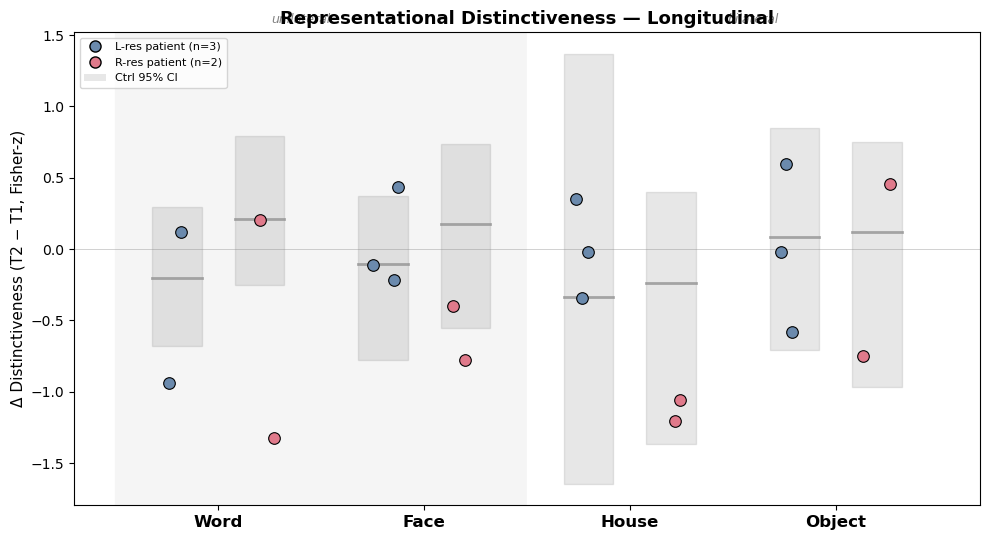

In [32]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL: Distinctiveness — longitudinal Δ
# ═══════════════════════════════════════════════════════════════════════════

CATS_ORDERED = ['word', 'face', 'house', 'object']
LABELS = {'word': 'Word', 'face': 'Face', 'house': 'House', 'object': 'Object'}
VCOL = 'liu_distinctiveness'
CTRL_COLOR = '#888888'

# Build Δ from df_liu (longitudinal subs only)
ses_counts = df_liu.groupby('subject_id')['session'].nunique()
long_liu = ses_counts[ses_counts >= 2].index
df_liu_long = df_liu[df_liu['subject_id'].isin(long_liu)].copy()

# First + last session per subject
df_liu_long = df_liu_long.sort_values(['subject_id', 'session'])
liu_t1 = df_liu_long.drop_duplicates(['subject_id', 'category', 'hemi_label'], keep='first')
liu_tl = df_liu_long.drop_duplicates(['subject_id', 'category', 'hemi_label'], keep='last')

delta_rows = []
for _, r1 in liu_t1.iterrows():
    r2 = liu_tl[(liu_tl['subject_id']==r1['subject_id']) &
                (liu_tl['category']==r1['category']) &
                (liu_tl['hemi_label']==r1['hemi_label'])]
    if r2.empty or r2['session'].values[0] == r1['session']: continue
    delta_rows.append({
        'sub': r1['subject_id'],
        'group': r1['group'],
        'status': r1['status'],
        'surgery_side': r1['surgery_side'],
        'hemi_label': r1['hemi_label'],
        'category': r1['category'],
        'delta': r2[VCOL].values[0] - r1[VCOL],
    })
df_liu_delta = pd.DataFrame(delta_rows)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.axvspan(-0.5, 1.5, color='#F5F5F5', zorder=0)
ax.axvspan(1.5, 3.5, color='#FFFFFF', zorder=0)
ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)

for i, cat in enumerate(CATS_ORDERED):
    for res, hemi_ctrl in [('L-res', 'right'), ('R-res', 'left')]:
        ctrl_vals = df_liu_delta[(df_liu_delta['status']=='control') &
                                 (df_liu_delta['category']==cat) &
                                 (df_liu_delta['hemi_label']==hemi_ctrl)]['delta'].values
        if len(ctrl_vals) < 2: continue
        offset = -0.2 if res == 'L-res' else 0.2
        x = i + offset
        
        lo, hi = np.percentile(ctrl_vals, [2.5, 97.5])
        m = np.mean(ctrl_vals)
        ax.fill_between([x - 0.12, x + 0.12], [lo, lo], [hi, hi],
                        color=CTRL_COLOR, alpha=0.2, zorder=1)
        ax.plot([x - 0.12, x + 0.12], [m, m], color=CTRL_COLOR,
                linewidth=2, alpha=0.7, zorder=2)
        
        surgery_match = 'left' if res == 'L-res' else 'right'
        pt_vals = df_liu_delta[(df_liu_delta['group']=='OTC') &
                               (df_liu_delta['category']==cat) &
                               (df_liu_delta['hemi_label']=='intact') &
                               (df_liu_delta['surgery_side']==surgery_match)]['delta'].values
        jitter = np.random.default_rng(i*10 + (0 if res=='L-res' else 1)).uniform(-0.08, 0.08, len(pt_vals))
        ax.scatter(x + jitter, pt_vals, s=70, color=COLORS[res], edgecolor='black',
                   linewidth=0.8, zorder=4)

ax.set_xticks(range(4))
ax.set_xticklabels([LABELS[c] for c in CATS_ORDERED], fontsize=12, fontweight='bold')
ax.set_ylabel('Δ Distinctiveness (T2 − T1, Fisher-z)', fontsize=11)
ax.set_title('Representational Distinctiveness — Longitudinal', fontsize=13, fontweight='bold')
ax.text(0.25, 1.02, 'unilateral', transform=ax.transAxes, ha='center', style='italic', fontsize=9, color='gray')
ax.text(0.75, 1.02, 'bilateral', transform=ax.transAxes, ha='center', style='italic', fontsize=9, color='gray')

from matplotlib.patches import Patch
handles = [
    plt.Line2D([0],[0], marker='o', color=COLORS['L-res'], markeredgecolor='k',
               markersize=8, linestyle='', label='L-res patient (n=3)'),
    plt.Line2D([0],[0], marker='o', color=COLORS['R-res'], markeredgecolor='k',
               markersize=8, linestyle='', label='R-res patient (n=2)'),
    Patch(facecolor=CTRL_COLOR, alpha=0.2, label='Ctrl 95% CI'),
]
ax.legend(handles=handles, loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_distinctiveness_long.png', dpi=200)
plt.show()

### Statistical tests

Bootstrap CI (10K, LOO) group-level; Crawford-Howell per patient.

**Group-level flags:**
- R-res face below CI (Δ=−0.588, becoming more distinct while ctrls trend opposite)
- R-res word below CI (Δ=−0.559)
- House, object ns both sides

**Per-patient (Crawford):** only sub-008 word reaches significance (Δ=−1.325, p=.007). Drives R-res word group flag.

**Interpretation:** No category becomes less distinct. R-res patients trend toward sharper representations over time — consistent with recovery/continued specialization, not disruption.

## Geometry Preservation — Longitudinal (HEADLINE)

### Measure
Pearson correlation between upper-triangle elements of the 4×4 RDM (1 − corr of category betas) at T1 vs T2. Computed from raw betas (copes 15–18) within 6mm sphere around category peak. Higher r = more preserved category structure over time.

### Why this is the primary multivariate measure
Unlike distinctiveness (single-category dissociability), geometry captures the entire between-category structure. It asks: are the relationships among faces, houses, objects, words the same at T2 as at T1?

### Key test: within-patient uni vs bi
Paired t-test comparing each patient's mean geometry r for unilateral categories (face, word) vs bilateral categories (house, object). 5/5 patients show uni > bi; t(4)=4.378, p=.012.

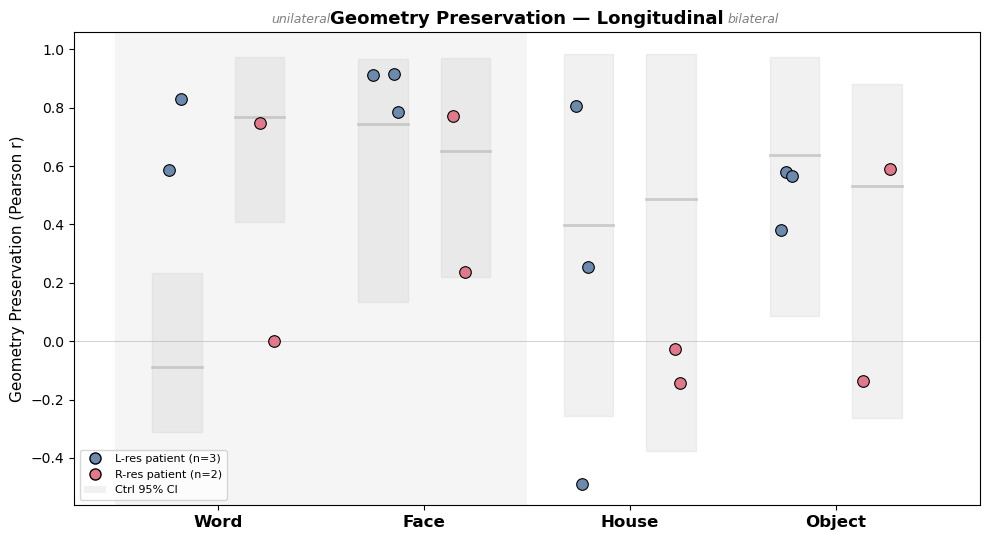

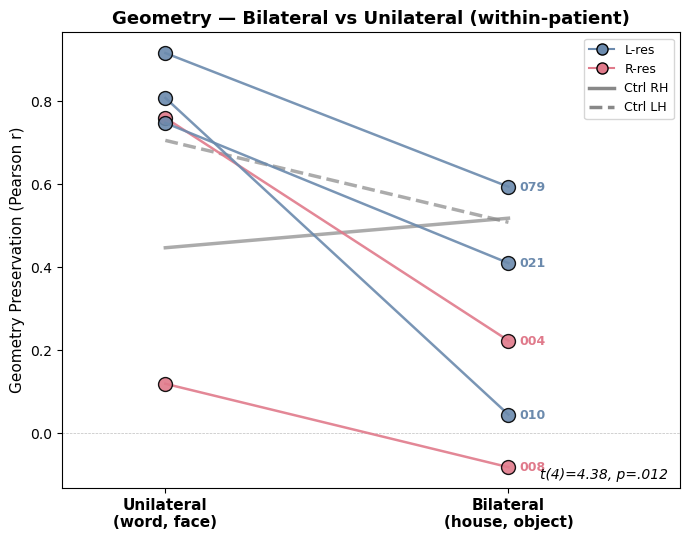

In [39]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL: Geometry Preservation — longitudinal (ctrl boxplot + patient labels)
# ═══════════════════════════════════════════════════════════════════════════

CATS_ORDERED = ['word', 'face', 'house', 'object']
LABELS = {'word': 'Word', 'face': 'Face', 'house': 'House', 'object': 'Object'}
VCOL = 'geometry_preservation'
CTRL_COLOR = '#BBBBBB'

# ── Figure 1: per-category with ctrl band + patient dots ────────────────
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.axvspan(-0.5, 1.5, color='#F5F5F5', zorder=0)
ax.axvspan(1.5, 3.5, color='#FFFFFF', zorder=0)
ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)

for i, cat in enumerate(CATS_ORDERED):
    for res, hemi_ctrl in [('L-res', 'right'), ('R-res', 'left')]:
        ctrl_vals = df_geo[(df_geo['status']=='control') &
                           (df_geo['category']==cat) &
                           (df_geo['hemi_label']==hemi_ctrl)][VCOL].dropna().values
        if len(ctrl_vals) < 2: continue
        offset = -0.2 if res == 'L-res' else 0.2
        x = i + offset
        
        lo, hi = np.percentile(ctrl_vals, [2.5, 97.5])
        m = np.mean(ctrl_vals)
        ax.fill_between([x - 0.12, x + 0.12], [lo, lo], [hi, hi],
                        color=CTRL_COLOR, alpha=0.2, zorder=1)
        ax.plot([x - 0.12, x + 0.12], [m, m], color=CTRL_COLOR,
                linewidth=2, alpha=0.7, zorder=2)
        
        surgery_match = 'left' if res == 'L-res' else 'right'
        pt_vals = df_geo[(df_geo['group']=='OTC') &
                         (df_geo['category']==cat) &
                         (df_geo['hemi_label']=='intact') &
                         (df_geo['surgery_side']==surgery_match)][VCOL].dropna().values
        jitter = np.random.default_rng(i*10 + (0 if res=='L-res' else 1)).uniform(-0.08, 0.08, len(pt_vals))
        ax.scatter(x + jitter, pt_vals, s=70, color=COLORS[res], edgecolor='black',
                   linewidth=0.8, zorder=4)

ax.set_xticks(range(4))
ax.set_xticklabels([LABELS[c] for c in CATS_ORDERED], fontsize=12, fontweight='bold')
ax.set_ylabel('Geometry Preservation (Pearson r)', fontsize=11)
ax.set_title('Geometry Preservation — Longitudinal', fontsize=13, fontweight='bold')
ax.text(0.25, 1.02, 'unilateral', transform=ax.transAxes, ha='center', style='italic', fontsize=9, color='gray')
ax.text(0.75, 1.02, 'bilateral', transform=ax.transAxes, ha='center', style='italic', fontsize=9, color='gray')

from matplotlib.patches import Patch
handles = [
    plt.Line2D([0],[0], marker='o', color=COLORS['L-res'], markeredgecolor='k', markersize=8, linestyle='', label='L-res patient (n=3)'),
    plt.Line2D([0],[0], marker='o', color=COLORS['R-res'], markeredgecolor='k', markersize=8, linestyle='', label='R-res patient (n=2)'),
    Patch(facecolor=CTRL_COLOR, alpha=0.2, label='Ctrl 95% CI'),
]
ax.legend(handles=handles, loc='lower left', fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_geometry_categories.png', dpi=200)
plt.show()

# ── Figure 2: slope with labels ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5, zorder=1)

pt_df = df_geo[(df_geo['group']=='OTC') & (df_geo['hemi_label']=='intact')]
for sub in pt_df['subject_id'].unique():
    sd = pt_df[pt_df['subject_id']==sub]
    uni = sd[sd['category'].isin(['word','face'])][VCOL].mean()
    bi  = sd[sd['category'].isin(['house','object'])][VCOL].mean()
    if pd.isna(uni) or pd.isna(bi): continue
    res = 'L-res' if sd['surgery_side'].iloc[0]=='left' else 'R-res'
    ax.plot([0,1], [uni, bi], '-o', color=COLORS[res], markersize=10,
            markeredgecolor='black', linewidth=1.8, alpha=0.9, zorder=3)
    ax.annotate(sub.replace('sub-',''), (1, bi), fontsize=9, fontweight='bold',
                color=COLORS[res], xytext=(8, -3), textcoords='offset points')

# Ctrl reference lines (uni vs bi mean per hemi)
for hemi_ctrl, label, style in [('right', 'Ctrl RH (L-res ref)', '-'),
                                 ('left',  'Ctrl LH (R-res ref)', '--')]:
    ctrl_sub = df_geo[(df_geo['status']=='control') & (df_geo['hemi_label']==hemi_ctrl)]
    uni_ctrl = ctrl_sub[ctrl_sub['category'].isin(['word','face'])][VCOL].mean()
    bi_ctrl  = ctrl_sub[ctrl_sub['category'].isin(['house','object'])][VCOL].mean()
    ax.plot([0, 1], [uni_ctrl, bi_ctrl], linestyle=style, color='#888888',
            linewidth=2.5, alpha=0.7, zorder=2, label=label)
    
ax.set_xticks([0, 1])
ax.set_xticklabels(['Unilateral\n(word, face)', 'Bilateral\n(house, object)'],
                    fontsize=11, fontweight='bold')
ax.set_xlim(-0.3, 1.5)
ax.set_ylabel('Geometry Preservation (Pearson r)', fontsize=11)
ax.set_title('Geometry — Bilateral vs Unilateral (within-patient)', fontsize=13, fontweight='bold')
ax.text(0.98, 0.02, 't(4)=4.38, p=.012', transform=ax.transAxes, ha='right',
        fontsize=10, style='italic')

handles = [plt.Line2D([0],[0], marker='o', color=COLORS[k], markeredgecolor='k',
                       markersize=8, label=k) for k in ['L-res', 'R-res']]
handles += [plt.Line2D([0],[0], linestyle='-',  color='#888888', linewidth=2.5, label='Ctrl RH'),
            plt.Line2D([0],[0], linestyle='--', color='#888888', linewidth=2.5, label='Ctrl LH')]
ax.legend(handles=handles, loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_geometry_slope.png', dpi=200)
plt.show()

### Statistical tests

**Headline (within-patient paired t):** uni M=0.671 > bi M=0.238, t(4)=4.378, p=.012. Every patient shows uni > bi. Excluding sub-008 (hemispherectomy): p=.018. Diff-of-diff vs ctrl: p=.049.

**Per-category (bootstrap CI):**
- L-res word elevated (0.708 vs ctrl CI [-0.295, 0.193]) — retained structure on non-preferred hemi
- R-res word reduced (0.375 vs ctrl CI [0.471, 0.952])
- House, object, face ns both sides

**Per-patient (Crawford):** sub-008 word t=-3.35 p=.012; sub-010 house t=-1.60 p=.006. Others ns.

**Control ROI (EVC):** ns both sides — effects specific to category-selective cortex.

## Cosine Stability — Longitudinal

Cosine stability asks: does each voxel respond the same way to the four categories at T2 as it did at T1? For each voxel we have a 4-element beta vector (face, house, object, word) at each timepoint; cosine similarity of those two vectors = stability of that voxel's tuning profile. We report this at two spatial scales.

### Figure A — Overall VOTC
Mean cosine across all voxels selective for at least one category at T1 (z>2.3) within the full VOTC mask. One number per subject × hemisphere. Answers: is VOTC as a whole less stable in patients?

### Figure B — Per-category searchmask
Mean cosine restricted to voxels within each category's anatomical searchmask (Harvard-Oxford). One number per subject × hemisphere × category. Answers: which categories' tissue is most disrupted?

### Why two scales
Overall cosine is an aggregate disruption measure — good for patient-vs-control group claims. Per-category searchmask cosine localizes disruption to the tissue that would normally host each category, avoiding the WTA-mislabeling issue that occurs when patients' peaks are already atypical at T1.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL: Compute per-category searchmask cosine (longitudinal)
# ═══════════════════════════════════════════════════════════════════════════

import nibabel as nib
from scipy.spatial.distance import cosine as cosine_dist

CATEGORIES_COS = ['face', 'house', 'object', 'word']
RSA_COPES = {'face': 15, 'house': 16, 'object': 17, 'word': 18}
Z_THRESH = 2.3

def load_betas_in_mask(sub, ses, first_ses, mask, cope_map):
    """Load raw betas (copes 15-18) for all 4 categories within mask."""
    feat = f'{processed_dir}/{sub}/ses-{ses:02d}/derivatives/fsl/loc/HighLevel.gfeat'
    cn = 'cope1.nii.gz' if ses == first_ses else f'cope1_ses{first_ses:02d}.nii.gz'
    betas = {}
    for cat in CATEGORIES_COS:
        cf = f'{feat}/cope{cope_map[cat]}.feat/stats/{cn}'
        if not os.path.exists(cf):
            return None
        betas[cat] = nib.load(cf).get_fdata()[mask]
    return betas

def compute_searchmask_cosine(sub, hemi, t1_ses, t2_ses, first_ses):
    """Pattern stability per category within its searchmask (T1 vs T2 beta pattern)."""
    results = {}
    roi_dir = f'{processed_dir}/{sub}/ses-{first_ses:02d}/ROIs'
    for cat in CATEGORIES_COS:
        mask_path = f'{roi_dir}/{hemi}_{cat}_searchmask.nii.gz'
        if not os.path.exists(mask_path): continue
        mask = nib.load(mask_path).get_fdata().astype(bool)
        
        b1 = load_betas_in_mask(sub, t1_ses, first_ses, mask, RSA_COPES)
        b2 = load_betas_in_mask(sub, t2_ses, first_ses, mask, RSA_COPES)
        if b1 is None or b2 is None: continue
        
        # Pattern for THIS category only
        p1, p2 = b1[cat], b2[cat]
        valid = np.isfinite(p1) & np.isfinite(p2)
        p1, p2 = p1[valid], p2[valid]
        if len(p1) < 10 or np.linalg.norm(p1) == 0 or np.linalg.norm(p2) == 0:
            continue
        
        # Cosine between T1 and T2 pattern vectors
        results[cat] = 1 - cosine_dist(p1, p2)
    return results

# Identify longitudinal subjects
from sym_pt_params import get_sessions, get_sub_info

cos_cat_rows = []
# Loop over OTC + control longitudinal subs
long_sel = df_sel.groupby('sub')['ses'].nunique()
long_subs_list = long_sel[long_sel >= 2].index.tolist()

for sub in long_subs_list:
    sub_clean = sub.replace('sub-', '')
    sessions = sorted(get_sessions(sub_clean))
    if len(sessions) < 2: continue
    t1_ses, t2_ses = sessions[0], sessions[-1]
    first_ses = sessions[0]
    
    info = get_sub_info(sub_clean, t1_ses)
    group = info.get('group', 'unknown')
    surgery_side = info.get('surgery_side', 'na')
    intact_hemi = info.get('intact_hemi', 'na')
    
    hemis = ['l', 'r'] if group == 'control' else [intact_hemi[0]]
    
    for h in hemis:
        cat_cos = compute_searchmask_cosine(sub, h, t1_ses, t2_ses, first_ses)
        for cat, val in cat_cos.items():
            cos_cat_rows.append({
                'sub': sub, 'hemi': h, 'category': cat,
                'group': group, 'surgery_side': surgery_side,
                'intact_hemi': intact_hemi, 'cosine': val,
            })

df_cos_cat = pd.DataFrame(cos_cat_rows)
print(f'Computed: {df_cos_cat["sub"].nunique()} subjects, {len(df_cos_cat)} rows')

# Optional: save for future use
df_cos_cat.to_csv(f'{processed_dir}/group_results/searchmask_cosine_long.csv', index=False)

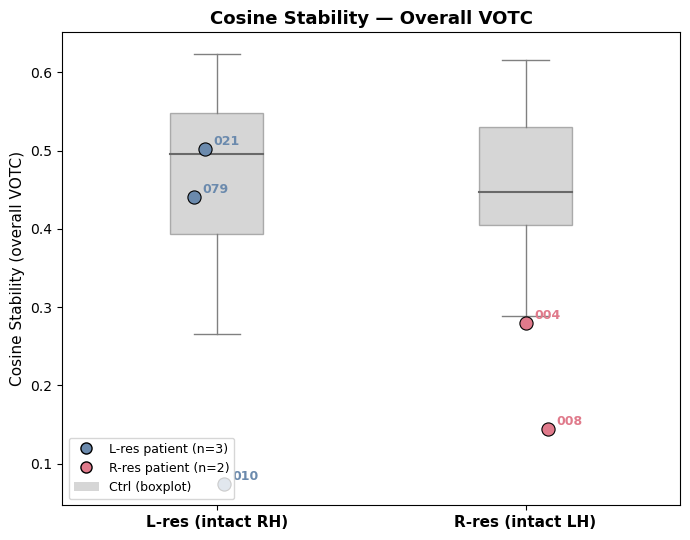

In [44]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL: Figure A — Overall VOTC cosine (group-level)
# ═══════════════════════════════════════════════════════════════════════════

COS_PATH = '/user_data/csimmon2/sym_pt/group_results/voxel_allegiance_summary_cat_vs_all.csv'
df_cos_overall = pd.read_csv(COS_PATH)
df_cos_overall = df_cos_overall[~df_cos_overall['sub'].isin(EXCLUDE)]

VCOL = 'mean_cos_sim'
CTRL_COLOR = '#BBBBBB'

fig, ax = plt.subplots(figsize=(7, 5.5))

for i, (res, hemi_ctrl) in enumerate([('L-res', 'r'), ('R-res', 'l')]):
    ctrl_vals = df_cos_overall[(df_cos_overall['group']=='control') &
                                (df_cos_overall['hemi']==hemi_ctrl)][VCOL].dropna().values
    ax.boxplot([ctrl_vals], positions=[i], widths=0.3,
               patch_artist=True, showfliers=False,
               boxprops=dict(facecolor=CTRL_COLOR, edgecolor='gray', alpha=0.6),
               medianprops=dict(color='dimgray', linewidth=1.5),
               whiskerprops=dict(color='gray'), capprops=dict(color='gray'), zorder=2)
    
    surgery_match = 'left' if res == 'L-res' else 'right'
    pts = df_cos_overall[(df_cos_overall['group']=='OTC') &
                         (df_cos_overall['surgery_side']==surgery_match) &
                         (df_cos_overall['hemi']==hemi_ctrl)][['sub', VCOL]].dropna()
    
    jitter = np.random.default_rng(i).uniform(-0.08, 0.08, len(pts))
    for j, (_, r) in enumerate(pts.iterrows()):
        xj = i + jitter[j]
        ax.scatter(xj, r[VCOL], s=90, color=COLORS[res], edgecolor='black',
                   linewidth=0.8, zorder=4)
        ax.annotate(r['sub'].replace('sub-',''), (xj, r[VCOL]),
                    fontsize=9, fontweight='bold', color=COLORS[res],
                    xytext=(6, 3), textcoords='offset points', zorder=5)

ax.set_xticks([0, 1])
ax.set_xticklabels(['L-res (intact RH)', 'R-res (intact LH)'], fontsize=11, fontweight='bold')
ax.set_xlim(-0.5, 1.5)
ax.set_ylabel('Cosine Stability (overall VOTC)', fontsize=11)
ax.set_title('Cosine Stability — Overall VOTC', fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
handles = [
    plt.Line2D([0],[0], marker='o', color=COLORS['L-res'], markeredgecolor='k', markersize=8, linestyle='', label='L-res patient (n=3)'),
    plt.Line2D([0],[0], marker='o', color=COLORS['R-res'], markeredgecolor='k', markersize=8, linestyle='', label='R-res patient (n=2)'),
    Patch(facecolor=CTRL_COLOR, alpha=0.6, label='Ctrl (boxplot)'),
]
ax.legend(handles=handles, loc='lower left', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_cosine_overall.png', dpi=200)
plt.show()

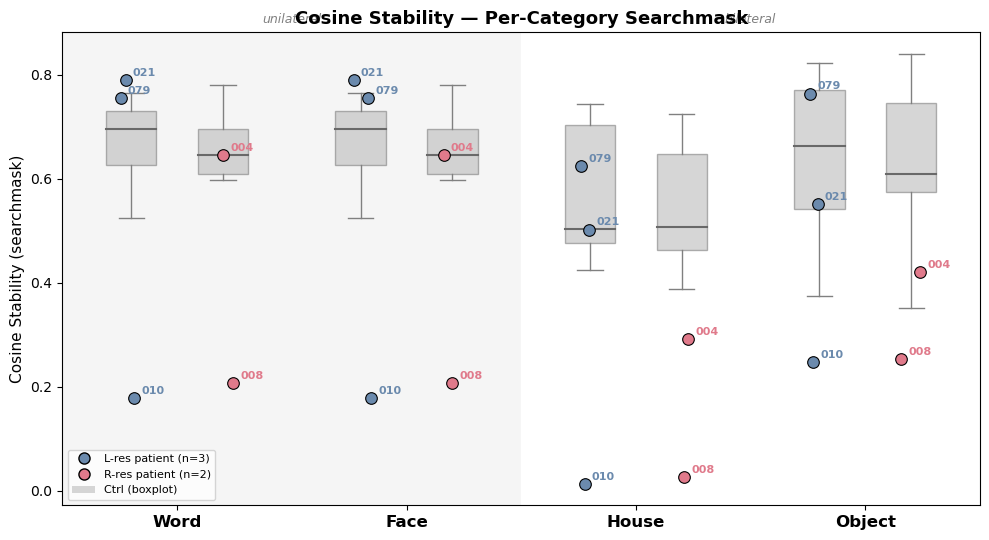

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL: Figure B — Per-category searchmask cosine
# ═══════════════════════════════════════════════════════════════════════════

CATS_ORDERED = ['word', 'face', 'house', 'object']
LABELS = {'word': 'Word', 'face': 'Face', 'house': 'House', 'object': 'Object'}
VCOL = 'cosine'
CTRL_COLOR = '#BBBBBB'

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.axvspan(-0.5, 1.5, color='#F5F5F5', zorder=0)
ax.axvspan(1.5, 3.5, color='#FFFFFF', zorder=0)

for i, cat in enumerate(CATS_ORDERED):
    for res, hemi_ctrl in [('L-res', 'r'), ('R-res', 'l')]:
        offset = -0.2 if res == 'L-res' else 0.2
        x = i + offset
        
        ctrl_vals = df_cos_cat[(df_cos_cat['group']=='control') &
                               (df_cos_cat['category']==cat) &
                               (df_cos_cat['hemi']==hemi_ctrl)][VCOL].dropna().values
        if len(ctrl_vals) < 2: continue
        
        ax.boxplot([ctrl_vals], positions=[x], widths=0.22,
                   patch_artist=True, showfliers=False,
                   boxprops=dict(facecolor=CTRL_COLOR, edgecolor='gray', alpha=0.6),
                   medianprops=dict(color='dimgray', linewidth=1.5),
                   whiskerprops=dict(color='gray'),
                   capprops=dict(color='gray'), zorder=2)
        
        surgery_match = 'left' if res == 'L-res' else 'right'
        pts = df_cos_cat[(df_cos_cat['group']=='OTC') &
                         (df_cos_cat['category']==cat) &
                         (df_cos_cat['surgery_side']==surgery_match) &
                         (df_cos_cat['hemi']==hemi_ctrl)][['sub', VCOL]].dropna()
        
        jitter = np.random.default_rng(i*10 + (0 if res=='L-res' else 1)).uniform(-0.05, 0.05, len(pts))
        for j, (_, r) in enumerate(pts.iterrows()):
            xj = x + jitter[j]
            ax.scatter(xj, r[VCOL], s=70, color=COLORS[res], edgecolor='black',
                       linewidth=0.8, zorder=4)
            ax.annotate(r['sub'].replace('sub-',''), (xj, r[VCOL]),
                        fontsize=8, fontweight='bold', color=COLORS[res],
                        xytext=(5, 3), textcoords='offset points', zorder=5)

ax.set_xticks(range(4))
ax.set_xticklabels([LABELS[c] for c in CATS_ORDERED], fontsize=12, fontweight='bold')
ax.set_xlim(-0.5, 3.5)
ax.set_ylabel('Cosine Stability (searchmask)', fontsize=11)
ax.set_title('Cosine Stability — Per-Category Searchmask', fontsize=13, fontweight='bold')
ax.text(0.25, 1.02, 'unilateral', transform=ax.transAxes, ha='center', style='italic', fontsize=9, color='gray')
ax.text(0.75, 1.02, 'bilateral', transform=ax.transAxes, ha='center', style='italic', fontsize=9, color='gray')

handles = [
    plt.Line2D([0],[0], marker='o', color=COLORS['L-res'], markeredgecolor='k', markersize=8, linestyle='', label='L-res patient (n=3)'),
    plt.Line2D([0],[0], marker='o', color=COLORS['R-res'], markeredgecolor='k', markersize=8, linestyle='', label='R-res patient (n=2)'),
    Patch(facecolor=CTRL_COLOR, alpha=0.6, label='Ctrl (boxplot)'),
]
ax.legend(handles=handles, loc='lower left', fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_cosine_searchmask.png', dpi=200)
plt.show()

### Statistical tests

**Overall VOTC (Figure A):** Bootstrap CI. L-res 0.339 vs ctrl CI [0.385, 0.551]*; R-res 0.212 vs ctrl CI [0.386, 0.535]* — both below ctrl, supports group-level disruption claim.

**Per-category searchmask (Figure B):** Crawford-Howell per patient. [Run Crawford on df_cos_cat once computed; pattern expected to show bilateral > unilateral disruption if symmetry framework holds.]